# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


### ANSWERS
2.1 Done in code below.

2.2 The values for each coefficients were Debtor: 0.531, Tuition fees up to date: -2.557, Scholarship holder: -1.227, Age at enrollment: 0.050. Analyzing these points, the variables that predict a higher dropout probability are Debtor and Age at enrollment since the coefficients are positive. On the other hand, the variables that predict a lower dropout probability are Tuition fees up to date and Scholarship holder, since the coefficients are negative. Out of all of these variables, Tuition fees up to date reduces dropout risk the most due to it having the largest negative coefficient in magnitude.

2.3 The values for average change in predicted dropout probability were Debtor: +0.095, Tuition fees up to date: -0.516, Scholarship holder: -0.182, Age at enrollment (+1 year): +0.008. From this information, it can be seen that on average, being up to date on tuition lowers the predicted dropout probability by about 0.516, which is the biggest reduction out of the predictors in this model.

2.4 The accuracy of the classifier was about 0.762. Using the confusion matrix we got: 
$$
\begin{bmatrix}
2841 & 162 \\
891 & 530
\end{bmatrix}
$$
This shows that although the model is pretty accurate, it still misses a good number of actual dropouts.

2.5 The logistic regression predictions stay between 0 and 1, which is ideal in terms of probability. The linear model can still give something directionally useful, but is less appropriate in this context because it is not naturally built for binary outcomes.

2.6 Based on this model, the students who look most at risk of dropping out are the ones who are debtors, not up to date on tuition, not scholarship holders, and older at enrollment. A reasonable intervention could include financial support or outreach first, especially for those with unpaid tuition and debt status, since those look like the biggest warning signs in this model. In addition, academic advising and check-ins could help for students who also seem to be struggling early on.

2.7 The multinomial logistic model had an accuracy about 0.705. Something important that popped up is that the hard classification never predicted the Enrolled class, but instead only predicted Dropout and Graduate. In other words, it means the model can still assign nonzero probabilities to Enrolled, but those probabilities are never the largest for any observation, so the final hard class never ends up being Enrolled. In conclusion, this is a good example of why it helps to look at both predict() and predict_proba() and not just the hard classification output.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, accuracy_score
plt.rcParams["figure.figsize"] = (8,5)

data = pd.read_csv('data/data.csv', sep=';')

q2_cols = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]

q2 = data[q2_cols].copy()

# Binary target: 1 = dropout, 0 = not dropout
q2['Dropout'] = (q2['Target'] == 'Dropout').astype(int)

print(q2.isna().sum())
print(q2.head())

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
Dropout                                0
dtype: int64
   Debtor  Tuition fees up to date  Scholarship holder  Age at enrollment  \
0       0                        1                   0                 20   
1       0                        0                   0                 19   
2       0                        0                   0                 19   
3       0                        1                   0                 20   
4       0                        1                   0                 45   

   Curricular units 1st sem (approved)    Target  Dropout  
0                                    0   Dropout        1  
1                                    6  Graduate        0  
2                                    0   Dropout        1

In [2]:
X_q2 = q2[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y_q2 = q2['Dropout']

logit_q2 = LogisticRegression(max_iter=10000)
logit_q2.fit(X_q2, y_q2)

coef_q2 = pd.DataFrame({
    'feature': X_q2.columns,
    'coefficient': logit_q2.coef_[0]
})
coef_q2

,feature,coefficient
0,Debtor,0.530625
1,Tuition fees up to date,-2.556542
2,Scholarship holder,-1.227442
3,Age at enrollment,0.049925


In [3]:
pred_prob_q2 = logit_q2.predict_proba(X_q2)[:, 1]

avg_effects_q2 = {}

for var in ['Debtor', 'Tuition fees up to date', 'Scholarship holder']:
    X0 = X_q2.copy()
    X1 = X_q2.copy()
    X0[var] = 0
    X1[var] = 1
    diff = logit_q2.predict_proba(X1)[:, 1] - logit_q2.predict_proba(X0)[:, 1]
    avg_effects_q2[var] = diff.mean()

X_age = X_q2.copy()
X_age['Age at enrollment'] = X_age['Age at enrollment'] + 1
avg_effects_q2['Age at enrollment (+1 year)'] = (logit_q2.predict_proba(X_age)[:,1] - pred_prob_q2).mean()

avg_effects_q2

{'Debtor': 0.09494953450351795,
 'Tuition fees up to date': -0.5161819741857507,
 'Scholarship holder': -0.18238439399509798,
 'Age at enrollment (+1 year)': 0.008293832686653794}

In [4]:
pred_class_q2 = logit_q2.predict(X_q2)
acc_q2 = accuracy_score(y_q2, pred_class_q2)
cm_q2 = confusion_matrix(y_q2, pred_class_q2)

acc_q2, cm_q2

(0.7619801084990958,
 array([[2841,  162],
        [ 891,  530]]))

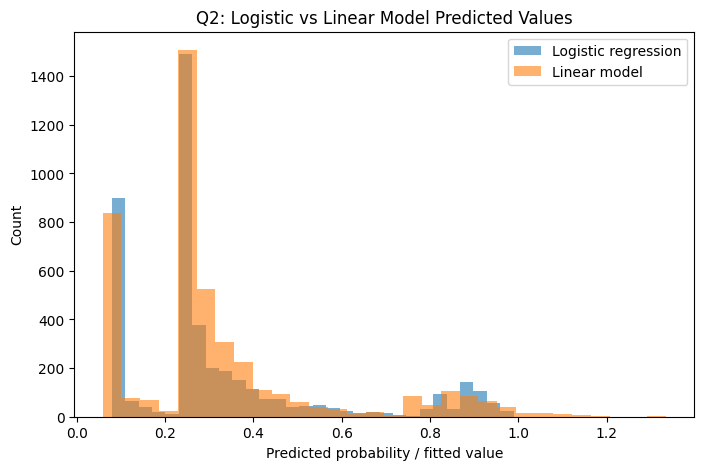

Linear model coefficients:
                   feature  coefficient
0                   Debtor     0.085183
1  Tuition fees up to date    -0.512166
2       Scholarship holder    -0.176472
3        Age at enrollment     0.009487


In [5]:
lin_q2 = LinearRegression()
lin_q2.fit(X_q2, y_q2)
pred_lin_q2 = lin_q2.predict(X_q2)

plt.figure()
plt.hist(pred_prob_q2, bins=30, alpha=0.6, label='Logistic regression')
plt.hist(pred_lin_q2, bins=30, alpha=0.6, label='Linear model')
plt.xlabel('Predicted probability / fitted value')
plt.ylabel('Count')
plt.title('Q2: Logistic vs Linear Model Predicted Values')
plt.legend()
plt.show()

print('Linear model coefficients:')
print(pd.DataFrame({'feature': X_q2.columns, 'coefficient': lin_q2.coef_}))

In [6]:
X_q2_multi = q2[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_q2_multi = q2['Target']

multi_q2 = LogisticRegression(max_iter=10000)
multi_q2.fit(X_q2_multi, y_q2_multi)

pred_multi_q2 = multi_q2.predict(X_q2_multi)
prob_multi_q2 = multi_q2.predict_proba(X_q2_multi)

acc_multi_q2 = accuracy_score(y_q2_multi, pred_multi_q2)
cm_multi_q2 = confusion_matrix(y_q2_multi, pred_multi_q2, labels=multi_q2.classes_)

print('Classes:', multi_q2.classes_)
print('Accuracy:', acc_multi_q2)
print('Confusion matrix:')
print(cm_multi_q2)

pd.DataFrame(prob_multi_q2, columns=multi_q2.classes_).head()

Classes: ['Dropout' 'Enrolled' 'Graduate']
Accuracy: 0.7045660036166366
Confusion matrix:
[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


,Dropout,Enrolled,Graduate
0,0.680547,0.210464,0.108989
1,0.695414,0.146043,0.158543
2,0.952988,0.041199,0.005813
3,0.117808,0.176983,0.705209
4,0.184227,0.212669,0.603104


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

### ANSWERS

3.1 Done in code below.

3.2 The coefficient values were Edema_S: -0.451, Edema_Y: -1.611, Drug_Placebo: 0.231, Bilirubin: -0.351. In this model, higher Bilirubin predicts a lower survival probability while worse Edema status also predicts a lower survival probability. Meanwhile, the coefficient on Drug_Placebo is positive, which means the model is estimating higher survival under placebo than under D-penicillamine, holding the other included variables fixed. Therefore, the drug does not look like it improves survival probability.

3.3 The average effect of switching from Placebo to D-penicillamine was about -0.042, which means the fitted model says the drug lowers survival probability slightly on average rather than increasing it. For Bilirubin, a 1-unit increase lowered predicted survival probability by about 0.067 on average, so higher bilirubin clearly points toward worse survival in this model. The average predicted survival probability by edema status was N: 0.618, S: 0.530, Y: 0.292. In conclusion, survival gets worse as edema becomes more severe, which is the pattern we would expect.

3.4 The classifier accuracy was about 0.737. The confusion matrix was: 
$$
\begin{bmatrix}
59 & 66 \\
16 & 171
\end{bmatrix}
$$

In other words, the model was much better at identifying people who survived than people who died.

3.5 The logistic regression is the cleaner probability model here since its predictions stay in the 0 to 1 range. The linear model can still be used for comparison, but it is less natural for a binary survival outcome.

3.6 The multinomial logistic model for Stage had an accuracy about 0.439. What stands out is that the hard classification only predicted Stage 3 and Stage 4, but never predicted Stage 1 or Stage 2 as the final class. In conclusion, the predicted probabilities matter. The model still gives probabilities for all stages, but the highest probability was never Stage 1 or Stage 2 for any observation, so those classes never showed up in the hard predictions.

In [7]:
cir = pd.read_csv('data/cirrhosis.csv')

q3 = cir[['Status', 'Edema', 'Drug', 'Bilirubin', 'Stage']].copy()

print(q3.isna().sum())

# For the binary survival model, keep rows with complete values in the variables used
q3_bin = q3[['Status', 'Edema', 'Drug', 'Bilirubin']].dropna().copy()

# Binary survival target: 1 = alive (C or CL), 0 = dead (D)
q3_bin['Survive'] = q3_bin['Status'].isin(['C', 'CL']).astype(int)

print(q3_bin.head())
print(q3_bin.shape)

Status         0
Edema          0
Drug         106
Bilirubin      0
Stage          6
dtype: int64
  Status Edema             Drug  Bilirubin  Survive
0      D     Y  D-penicillamine       14.5        0
1      C     N  D-penicillamine        1.1        1
2      D     S  D-penicillamine        1.4        0
3      D     S  D-penicillamine        1.8        0
4     CL     N          Placebo        3.4        1
(312, 5)


In [8]:
X_q3 = q3_bin[['Edema', 'Drug', 'Bilirubin']]
y_q3 = q3_bin['Survive']

pre_q3 = ColumnTransformer([
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oh', OneHotEncoder(drop='first', sparse_output=False))
    ]), ['Edema', 'Drug']),
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median'))
    ]), ['Bilirubin'])
])

logit_q3 = Pipeline([
    ('pre', pre_q3),
    ('model', LogisticRegression(max_iter=10000))
])

logit_q3.fit(X_q3, y_q3)

oh_q3 = logit_q3.named_steps['pre'].named_transformers_['cat'].named_steps['oh']
feature_names_q3 = list(oh_q3.get_feature_names_out(['Edema', 'Drug'])) + ['Bilirubin']

coef_q3 = pd.DataFrame({
    'feature': feature_names_q3,
    'coefficient': logit_q3.named_steps['model'].coef_[0]
})

coef_q3

,feature,coefficient
0,Edema_S,-0.450677
1,Edema_Y,-1.611049
2,Drug_Placebo,0.231225
3,Bilirubin,-0.351424


In [9]:
pred_prob_q3 = logit_q3.predict_proba(X_q3)[:, 1]

X_placebo = X_q3.copy()
X_drug = X_q3.copy()
X_placebo['Drug'] = 'Placebo'
X_drug['Drug'] = 'D-penicillamine'

avg_drug_effect_q3 = (logit_q3.predict_proba(X_drug)[:, 1] - logit_q3.predict_proba(X_placebo)[:, 1]).mean()

X_bili = X_q3.copy()
X_bili['Bilirubin'] = X_bili['Bilirubin'] + 1
avg_bili_effect_q3 = (logit_q3.predict_proba(X_bili)[:, 1] - pred_prob_q3).mean()

edema_means = {}
for level in ['N', 'S', 'Y']:
    X_tmp = X_q3.copy()
    X_tmp['Edema'] = level
    edema_means[level] = logit_q3.predict_proba(X_tmp)[:, 1].mean()

avg_drug_effect_q3, avg_bili_effect_q3, edema_means

(-0.04242663943164004,
 -0.06729284376436219,
 {'N': 0.6183100241272481, 'S': 0.530226519687575, 'Y': 0.29235999672672824})

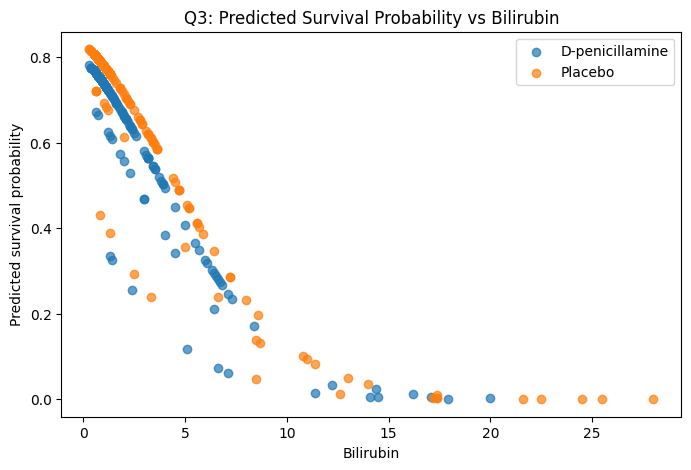

In [10]:
color_map = {'D-penicillamine': 'tab:blue', 'Placebo': 'tab:orange'}
colors = q3_bin['Drug'].map(color_map)

plt.figure()
for drug in q3_bin['Drug'].unique():
    mask = q3_bin['Drug'] == drug
    plt.scatter(
        q3_bin.loc[mask, 'Bilirubin'],
        pred_prob_q3[mask],
        alpha=0.7,
        label=drug
    )

plt.xlabel('Bilirubin')
plt.ylabel('Predicted survival probability')
plt.title('Q3: Predicted Survival Probability vs Bilirubin')
plt.legend()
plt.show()

In [11]:
pred_class_q3 = logit_q3.predict(X_q3)
acc_q3 = accuracy_score(y_q3, pred_class_q3)
cm_q3 = confusion_matrix(y_q3, pred_class_q3)

acc_q3, cm_q3

(0.7371794871794872,
 array([[ 59,  66],
        [ 16, 171]]))

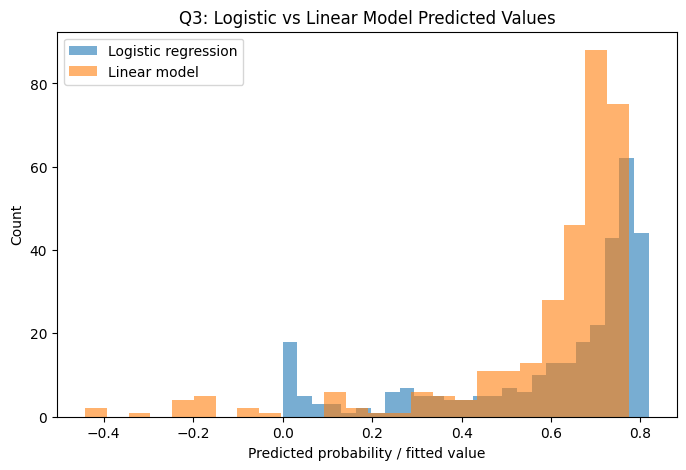

In [12]:
lin_q3 = Pipeline([
    ('pre', pre_q3),
    ('model', LinearRegression())
])

lin_q3.fit(X_q3, y_q3)
pred_lin_q3 = lin_q3.predict(X_q3)

plt.figure()
plt.hist(pred_prob_q3, bins=25, alpha=0.6, label='Logistic regression')
plt.hist(pred_lin_q3, bins=25, alpha=0.6, label='Linear model')
plt.xlabel('Predicted probability / fitted value')
plt.ylabel('Count')
plt.title('Q3: Logistic vs Linear Model Predicted Values')
plt.legend()
plt.show()

In [13]:
q3_stage = cir[['Stage', 'Edema', 'Bilirubin']].dropna().copy()

X_stage = q3_stage[['Edema', 'Bilirubin']]
y_stage = q3_stage['Stage'].astype(str)

pre_stage = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False), ['Edema']),
    ('num', 'passthrough', ['Bilirubin'])
])

stage_model = Pipeline([
    ('pre', pre_stage),
    ('model', LogisticRegression(max_iter=10000))
])

stage_model.fit(X_stage, y_stage)

pred_stage = stage_model.predict(X_stage)
prob_stage = stage_model.predict_proba(X_stage)

acc_stage = accuracy_score(y_stage, pred_stage)
cm_stage = confusion_matrix(y_stage, pred_stage, labels=stage_model.named_steps['model'].classes_)

print('Classes:', stage_model.named_steps['model'].classes_)
print('Accuracy:', acc_stage)
print('Confusion matrix:')
print(cm_stage)

pd.DataFrame(prob_stage, columns=stage_model.named_steps['model'].classes_).head()

Classes: ['1.0' '2.0' '3.0' '4.0']
Accuracy: 0.4393203883495146
Confusion matrix:
[[  0   0  20   1]
 [  0   0  82  10]
 [  0   0 130  25]
 [  0   0  93  51]]


,1.0,2.0,3.0,4.0
0,0.000469,0.051111,0.137332,0.811088
1,0.068675,0.255046,0.397581,0.278698
2,0.039844,0.139560,0.340088,0.480507
3,0.035217,0.137518,0.338843,0.488422
4,0.035049,0.243195,0.404019,0.317738


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 